%%%% Optimization time: 2.4998199939727783 seconds,   Cost: 0.4420757710816363 %%%%
[1]
[0 1 2 3]
[r**3] [1 r r**2 r**3]
%%%% Optimization time: 10.06990361213684 seconds,   Cost: 144.9551639017809 %%%%
[0]
[0 1 2 3]
[r] [1 r r**2 r**3]
%%%% Optimization time: 10.400690793991089 seconds,   Cost: 145.09507089337626 %%%%
[0 1]
[1 2 3]
[r r**3] [r r**2 r**3]
%%%% Optimization time: 0.892798900604248 seconds,   Cost: 10.612090100614102 %%%%
[0 1]
[0 2 3]
[r r**3] [1 r**2 r**3]


/home/samuel/anaconda3/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/home/samuel/anaconda3/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: invalid value encountered in matmul
  eAw = eAw @ eAw
/tmp/ipykernel_40996/3979039192.py:336: RuntimeWarning: overflow encountered in square
  V = np.sum(W[0, mask] * np.abs(f_tau[mask] - f_KM[mask]) ** 2) + np.sum(W[1, mask] * np.abs(a_tau[mask] - a_KM[mask]) ** 2)


%%%% Optimization time: 12.128840923309326 seconds,   Cost: 166.47654002110076 %%%%
[0 1]
[0 1 3]
[r r**3] [1 r r**3]
%%%% Optimization time: 11.742992401123047 seconds,   Cost: nan %%%%
[0 1]
[0 1 2]
[r r**3] [1 r r**2]
%%%% Optimization time: 12.232874393463135 seconds,   Cost: nan %%%%
Cost: 10.612090100614102
[ 163.84302352 -163.46016497    0.           37.85835875  -66.2407398
   28.17488666]
[1]
[1 2 3]
[r**3] [r r**2 r**3]
%%%% Optimization time: 0.6637279987335205 seconds,   Cost: 1.813678891698197 %%%%
[0]
[1 2 3]
[r] [r r**2 r**3]
%%%% Optimization time: 0.4426999092102051 seconds,   Cost: 1.8140089691144055 %%%%
[0 1]
[2 3]
[r r**3] [r**2 r**3]
%%%% Optimization time: 1.083423137664795 seconds,   Cost: 145.24092046810233 %%%%
[0 1]
[1 3]
[r r**3] [r r**3]
%%%% Optimization time: 1.5019242763519287 seconds,   Cost: 9.98810985823483 %%%%
[0 1]
[1 2]
[r r**3] [r r**2]
%%%% Optimization time: 1.0721731185913086 seconds,   Cost: 12.311803014036839 %%%%
Cost: 1.813678891698197
[ 0

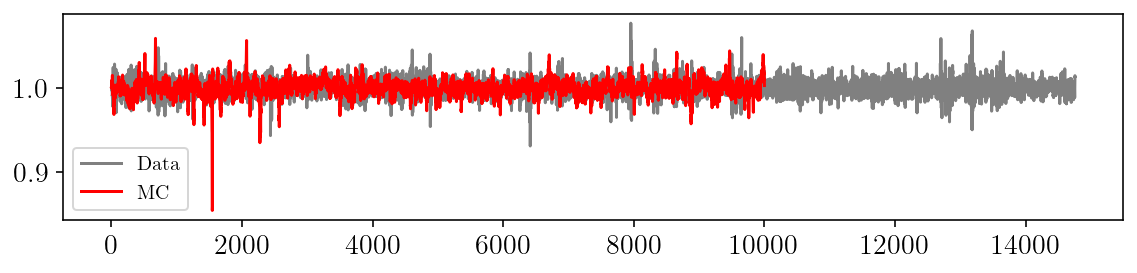

Saved results to 'lang_reg_results/' (Xi.npy, V.npy, Xi_f.npy, Xi_s.npy, r_centers.npy, f_KM.npy, a_KM.npy, data_cop.npy, X_MC.npy)


In [ ]:


from __future__ import annotations

import os
import struct
from typing import List, Tuple

import numpy as np
from numpy.linalg import lstsq, svd

import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import sympy as sp

# Local modules from the repo
import utils
import fpsolve

# Constants used in original notebook
Lx = 1024
Ly = 1024
DT = 2e-4


# ------------------------- I/O helpers -------------------------

def read_coords_from_file(file_path: str) -> Tuple[np.ndarray, np.ndarray]:
    """Read x y integer coordinates stored one pair per line.

    Lines must contain two integers separated by whitespace.
    Returns two numpy arrays (x_coords, y_coords).
    """
    x_coords, y_coords = [], []
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            x, y = map(int, parts[:2])
            x_coords.append(x)
            y_coords.append(y)
    return np.array(x_coords), np.array(y_coords)


def reconstruct_arrays_from_files(folder: str) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    """Collect files named coords_*.txt in `folder` and build lists of arrays.

    Returns (x_coords_over_time, y_coords_over_time).
    """
    files = sorted([f for f in os.listdir(folder) if f.startswith('coords_') and f.endswith('.txt')])
    x_all, y_all = [], []
    for fname in files:
        xp, yp = read_coords_from_file(os.path.join(folder, fname))
        x_all.append(xp)
        y_all.append(yp)
    return x_all, y_all


# ------------------------- Geometry helpers -------------------------

def shift_coordinates_periodically(x_list: np.ndarray, y_list: np.ndarray, Lx: float, Ly: float) -> Tuple[np.ndarray, np.ndarray]:
    """Shift coordinates so they are continuous relative to the first point.

    This handles periodic wrap-around across the domain [0, Lx) x [0, Ly).
    """
    x0, y0 = x_list[0], y_list[0]
    x_shifted = np.array([x - Lx if (abs(x - x0) > Lx / 2 and x > x0) else (x + Lx if (abs(x - x0) > Lx / 2 and x < x0) else x)
                          for x in x_list])
    y_shifted = np.array([y - Ly if (abs(y - y0) > Ly / 2 and y > y0) else (y + Ly if (abs(y - y0) > Ly / 2 and y < y0) else y)
                          for y in y_list])
    return x_shifted, y_shifted


def deal_with_periodic(recon_x: List[np.ndarray], recon_y: List[np.ndarray], N: int, Lx_val: float = Lx, Ly_val: float = Ly) -> Tuple[List[List[float]], List[List[float]]]:
    """Map reconstructed coords into regular angular bins and return filtered edges.

    For each time snapshot, points are converted to polar w.r.t. their centroid
    and the farthest point in each angular sector is taken.
    """
    x_all, y_all = [], []
    for xc_list, yc_list in zip(recon_x, recon_y):
        if len(xc_list) == 0:
            continue
        xs, ys = shift_coordinates_periodically(xc_list, yc_list, Lx_val, Ly_val)
        cx, cy = np.mean(xs), np.mean(ys)
        pts = np.column_stack((xs, ys))
        dists = np.hypot(pts[:, 0] - cx, pts[:, 1] - cy)
        angles = np.arctan2(pts[:, 1] - cy, pts[:, 0] - cx)

        disc_angles = np.linspace(-np.pi, np.pi, N, endpoint=False)
        filtered = []
        prev_point = None
        tol = (np.pi / N) + 0.005
        for ang in disc_angles:
            mask = (angles >= ang - tol) & (angles < ang + tol)
            if np.any(mask):
                idx = np.argmax(dists[mask])
                chosen = pts[mask][idx]
                prev_point = chosen
                filtered.append(tuple(chosen))
            elif prev_point is not None:
                filtered.append(tuple(prev_point))
        if filtered:
            x_all.append([f[0] for f in filtered])
            y_all.append([f[1] for f in filtered])
    return x_all, y_all


def find_height_field(x_all_list: List[List[float]], y_all_list: List[List[float]], N: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return mean-subtracted height field h_sub (shape [time,theta_points]), time array and theta.

    h_sub returned has shape (time, theta_samples).
    """
    h_store = []
    t_idx = []
    for ti in range(len(x_all_list)):
        if len(x_all_list[ti]) >= N:
            t_idx.append(ti)
            x_cm = np.mean(x_all_list[ti])
            y_cm = np.mean(y_all_list[ti])
            h_list = [np.hypot(x_all_list[ti][i] - x_cm, y_all_list[ti][i] - y_cm)
                      for i in range(len(x_all_list[ti]))]
            h_store.append(h_list)

    if not h_store:
        return np.empty((0, 0)), np.empty(0), np.empty(0)

    u = np.array(h_store)  # shape (time, theta)
    time_avg = np.mean(u, axis=0)
    h_sub = u - time_avg
    theta = np.linspace(0, 2 * np.pi, h_sub.shape[1], endpoint=False)

    ti_arr = np.array(t_idx)
    Tmax = DT * len(ti_arr)
    time_array = np.linspace(0, Tmax, len(ti_arr))
    return h_sub, time_array, theta


# ------------------------- Perimeter & deformation -------------------------

def calculate_perimeter(radius: np.ndarray, angles: np.ndarray) -> float:
    radius = np.asarray(radius)
    angles = np.asarray(angles)
    dr = np.diff(radius)
    dth = np.diff(angles)
    ds = np.sqrt(dr ** 2 + (radius[:-1] * dth) ** 2)
    return np.sum(ds)


def calc_deformation_pub(Q_sim: np.ndarray, Q_real: np.ndarray, t_range: Tuple[int, int] = (2000, 8000),
                         scale_factor: float = 50.0, fourier_modes: int = 900, t_max_plot: int = 1200) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Compute deformation Gamma for simulated and real Q arrays and plot results.

    Returns (gam_original, x_vals, pdf_data_norm, pdf_sim_norm, gam_original, gam_predict)
    to preserve the original notebook's return signature.
    """
    thetas = np.linspace(0, 2 * np.pi, Q_real.shape[0])
    peri_data, peri_sim, area_data, area_sim = [], [], [], []

    for i in range(*t_range):
        peri_data.append(calculate_perimeter(Q_real[:, i], thetas))
        peri_sim.append(calculate_perimeter(Q_sim[:, i], thetas))
        area_data.append(abs(np.trapz(Q_real[:, i], thetas)))
        area_sim.append(abs(np.trapz(Q_sim[:, i], thetas)))

    gam_original = (np.array(peri_data) / np.array(area_data)) - 1
    gam_predict = (np.array(peri_sim) / np.array(area_sim)) - 1

    # keep only low-frequency content (simple FFT truncation)
    def lowpass(signal, n_modes: int):
        n = len(signal)
        fft_vals = np.fft.fft(signal)
        freqs = np.fft.fftfreq(n)
        keep = np.argsort(np.abs(freqs))[:n_modes]
        truncated = np.zeros_like(fft_vals)
        truncated[keep] = fft_vals[keep]
        return np.fft.ifft(truncated).real

    gam_predict = scale_factor * lowpass(gam_predict, fourier_modes)
    gam_original = scale_factor * lowpass(gam_original, fourier_modes)
    gam_predict[0] = gam_original[0]

    # KDE comparison
    x_lo = min(gam_original[:t_max_plot].min(), gam_predict[:t_max_plot].min())
    x_hi = max(gam_original[:t_max_plot].max(), gam_predict[:t_max_plot].max())
    x_vals = np.linspace(x_lo, x_hi, 1000)
    pdf_data = gaussian_kde(gam_original[:t_max_plot])(x_vals)
    pdf_sim = gaussian_kde(gam_predict[:t_max_plot])(x_vals)
    pdf_data_norm = pdf_data / np.trapz(pdf_data, x_vals)
    pdf_sim_norm = pdf_sim / np.trapz(pdf_sim, x_vals)

    # Optional: small plots
    plt.figure(figsize=(4, 2))
    t = np.arange(len(gam_original))
    plt.plot(t[:t_max_plot], gam_original[:t_max_plot], color='k', lw=0.7, label='Original')
    plt.plot(t[:t_max_plot], gam_predict[:t_max_plot], color='r', lw=0.7, label='Predict')
    plt.legend()
    plt.tight_layout()

    return gam_original, x_vals, pdf_data_norm, pdf_sim_norm, gam_original, gam_predict


# ------------------------- Kramers-Moyal & SINDy/SSR pipeline -------------------------

def estimate_kramers_moyal(R: np.ndarray, r_edges: np.ndarray, lag: int, dt_val: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Estimate finite-time KM drift f_KM and diffusion a_KM on histogram bins.

    Returns (r_centers, f_KM, f_err, a_KM, a_err)
    """
    Nr = len(r_edges) - 1
    r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
    dX = (R[lag:] - R[:-lag]) / (lag * dt_val)
    dX2 = (R[lag:] - R[:-lag]) ** 2 / (lag * dt_val)

    f_KM = np.zeros(Nr)
    f_err = np.zeros(Nr)
    a_KM = np.zeros(Nr)
    a_err = np.zeros(Nr)

    for i in range(Nr):
        mask = (R[:-lag] > r_edges[i]) & (R[:-lag] < r_edges[i + 1])
        mask_idx = np.nonzero(mask)[0]
        if len(mask_idx) == 0:
            f_KM[i] = np.nan
            f_err[i] = np.nan
            a_KM[i] = np.nan
            a_err[i] = np.nan
            continue
        f_KM[i] = np.mean(dX[mask_idx])
        f_err[i] = np.std(dX[mask_idx]) / np.sqrt(len(mask_idx))
        a_KM[i] = 0.5 * np.mean(dX2[mask_idx])
        a_err[i] = np.std(dX2[mask_idx]) / np.sqrt(len(mask_idx))

    return r_centers, f_KM, f_err, a_KM, a_err


def build_sindy_libraries(r_centers: np.ndarray):
    """Construct simple polynomial libraries used in the notebook.

    Returns (f_expr, s_expr, lib_f, lib_s).
    """
    r_sym = sp.symbols('r')
    f_expr = [r_sym ** i for i in [1, 3]]
    s_expr = [r_sym ** i for i in range(0, 4)]

    def _eval_exprs(exprs):
        rows = []
        for expr in exprs:
            fn = sp.lambdify(r_sym, expr, 'numpy')
            vals = fn(r_centers)
            vals = np.asarray(vals)
            # Ensure scalars become arrays of the same length as r_centers
            if vals.ndim == 0:
                vals = np.full_like(r_centers, float(vals), dtype=float)
            rows.append(vals)
        return np.vstack(rows)

    lib_f = _eval_exprs(f_expr)
    lib_s = _eval_exprs(s_expr)
    # Return expression lists as numpy arrays to allow numpy-style indexing used in utils.SSR_loop
    return np.array(f_expr, dtype=object), np.array(s_expr, dtype=object), lib_f, lib_s


def run_ssr_and_select(R: np.ndarray, r_centers: np.ndarray, f_KM: np.ndarray, a_KM: np.ndarray, f_err: np.ndarray, a_err: np.ndarray, lag: int, dt_val: float):
    """Run SSR via the original utils.SSR_loop wrapper and return Xi and V arrays.

    This function prepares parameters and delegates the heavy lifting to
    existing helpers (fpsolve, utils). It mirrors the notebook's behaviour.
    """
    Nr = len(r_centers)
    f_expr, s_expr, lib_f, lib_s = build_sindy_libraries(r_centers)

    # initial least-squares estimate
    mask = np.nonzero(np.isfinite(f_KM))[0]
    Xi0 = np.zeros(len(f_expr) + len(s_expr))
    if mask.size:
        Xi0[:len(f_expr)] = lstsq(lib_f[:, mask].T, f_KM[mask], rcond=None)[0]
        Xi0[len(f_expr):] = lstsq(lib_s[:, mask].T, np.sqrt(2 * a_KM[mask]), rcond=None)[0]

    # weights
    W = np.vstack([f_err.flatten(), a_err.flatten()])
    W[np.less(np.abs(W), 1e-12, where=np.isfinite(W))] = 1e6
    W[~np.isfinite(W)] = 1e6
    W = 1 / W
    W /= np.nansum(W)

    p_hist = np.histogram(R, np.concatenate((r_centers - 0.5 * (r_centers[1] - r_centers[0]), [r_centers[-1] + 0.5 * (r_centers[1] - r_centers[0])])), density=True)[0]

    dr = r_centers[1] - r_centers[0]
    afp = fpsolve.AdjFP(r_centers)
    fp = fpsolve.SteadyFP(Nr, dr)

    params = {
        'W': W, 'f_KM': f_KM, 'a_KM': a_KM, 'Xi0': Xi0,
        'f_expr': f_expr, 's_expr': s_expr,
        'lib_f': lib_f.T, 'lib_s': lib_s.T, 'N': Nr,
        'kl_reg': 100,
        'fp': fp, 'afp': afp, 'p_hist': p_hist, 'tau': lag * dt_val,
        'radial': True, 'x_pts': r_centers,
    }

    opt_fun = lambda params_: utils.AFP_opt(cost_function, params_)
    Xi, V = utils.SSR_loop(opt_fun, params)
    return Xi, V, f_expr, s_expr, lib_f, lib_s


# A minimal cost wrapper that calls original 'utils' helpers; kept lightweight here

def cost_function(Xi: np.ndarray, params: dict) -> float:
    """Adapted cost function that delegates FP solves to provided solvers.

    This mirrors the notebook cost but keeps checks minimal.
    """
    W = params['W']
    f_KM = params['f_KM'].flatten()
    a_KM = params['a_KM'].flatten()
    lib_f = params['lib_f']
    lib_s = params['lib_s']
    N = params['N']

    # Drift and diffusion values from coefficients
    a_vals = 0.5 * (lib_s @ Xi[lib_f.shape[1]:]) ** 2
    f_vals = lib_f @ Xi[:lib_f.shape[1]]
    if params.get('radial', False):
        f_vals += a_vals / params.get('x_pts')

    afp = params['afp']
    fp = params['fp']
    # use afp solver if available
    if hasattr(afp, 'precompute_operator'):
        afp.precompute_operator(np.reshape(f_vals, N), np.reshape(a_vals, N))
        f_tau, a_tau = afp.solve(params['tau'])
    else:
        f_tau, a_tau = f_vals, a_vals

    mask = np.nonzero(np.isfinite(f_KM))[0]
    V = np.sum(W[0, mask] * np.abs(f_tau[mask] - f_KM[mask]) ** 2) + np.sum(W[1, mask] * np.abs(a_tau[mask] - a_KM[mask]) ** 2)

    # optional KL regularisation
    if params.get('kl_reg', 0) > 0 and 'fp' in params and 'p_hist' in params:
        p_est = params['fp'].solve(f_vals, a_vals) if hasattr(params['fp'], 'solve') else params['p_hist']
        kl = max(0, utils.kl_divergence(params['p_hist'], p_est, dx=params.get('fp').dx if 'fp' in params else None, tol=1e-6))
        V += params['kl_reg'] * kl
    return V


# ------------------------- Monte Carlo (Euler-Maruyama) -------------------------

def euler_maruyama(x0: float, f_func, a_func, delta_t: float, nsteps: int, scale: float = 1.0) -> np.ndarray:
    X = np.zeros(nsteps)
    x = x0
    X[0] = x
    for i in range(nsteps - 1):
        w = np.sqrt(scale * a_func(x) * delta_t) * np.random.randn()
        x = x + f_func(x) * delta_t + w
        # guard against invalid values
        if not np.isfinite(x):
            raise RuntimeError(f"Solution blew up at step {i}")
        X[i + 1] = x
    return X


# ------------------------- Main flow (example) -------------------------
lam=140
# Example: load a precomputed height-field (matching the notebook behaviour)
h_sub = np.loadtxt(f'h_files/h_{lam}.txt')  # shape (time_samples, theta_samples)
theta = np.linspace(0, 2 * np.pi, h_sub.shape[1], endpoint=False)

dt = DT
ti, tf = 0, 100000
u = np.array(h_sub).T[:, ti:tf]
t = np.arange(ti * dt, tf * dt, dt)
U, S, Vt = svd(u, full_matrices=False)
ri = 10
Ur = U[:, :ri]
Sr = np.diag(S[:ri])
modes = Vt[:ri, :]

    
    
n_sim = 3
cop = modes[n_sim, :] + 1
Ri = np.array(cop)
R = Ri / np.mean(Ri)

# histogram setup
Nr = 17
r_edges = np.linspace(np.min(R), np.max(R), Nr + 1)
r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])

# auto-correlation & Markov test (delegates to utils where used)
acf = utils.autocorr_func_1d(R)
lag = 13

r_centers, f_KM, f_err, a_KM, a_err = estimate_kramers_moyal(R, r_edges, lag, dt)

# build and run SSR (requires utils.SSR_loop wrapper)
Xi, V, f_expr, s_expr, lib_f, lib_s = run_ssr_and_select(R, r_centers, f_KM, a_KM, f_err, a_err, lag, dt)

# pick a sparsity level (mirrors notebook selection logic)
n_terms = 6
Xi_f = Xi[:len(f_expr), 1 - n_terms]
Xi_s = Xi[len(f_expr):, 1 - n_terms]

# create callable models
r_sym = sp.symbols('r')
s_sym = utils.sindy_model(Xi_s, s_expr)
a_sym = 0.5 * s_sym ** 2
f_sym = utils.sindy_model(Xi_f, f_expr)
s_sindy = sp.lambdify(r_sym, s_sym)
a_sindy = sp.lambdify(r_sym, a_sym)
f_sindy = sp.lambdify(r_sym, f_sym)

# small MC example (short)
x0 = float(cop[0])
# Short MC for quick smoke test; users can increase nsteps for final runs
X_MC = euler_maruyama(x0, lambda x: f_sindy(x), lambda x: a_sindy(x), dt, nsteps=10000, scale=2)

# plot time-series comparison
plt.figure(figsize=(8, 2))
data_plot = cop 
sim_plot = X_MC
plt.plot(data_plot, color='grey', label='Data')
plt.plot(sim_plot, color='red', label='MC')
plt.legend()
plt.tight_layout()
plt.show()

# --- Save key results to disk ---
save_dir = 'lang_reg_data6'
os.makedirs(save_dir, exist_ok=True)

    
# Coefficients and SSR outputs
np.save(os.path.join(save_dir, f'Xi_{lam}_{n_sim}.npy'), Xi)
np.save(os.path.join(save_dir, f'V_{lam}_{n_sim}.npy'), V)
np.save(os.path.join(save_dir, f'Xi_f_{lam}_{n_sim}.npy'), Xi_f)
np.save(os.path.join(save_dir, f'Xi_s_{lam}_{n_sim}.npy'), Xi_s)

# KM estimates and grid
np.save(os.path.join(save_dir, f'r_centers_{lam}_{n_sim}.npy'), r_centers)
np.save(os.path.join(save_dir, f'f_KM_{lam}_{n_sim}.npy'), f_KM)
np.save(os.path.join(save_dir, f'a_KM_{lam}_{n_sim}.npy'), a_KM)

# Time-series data
np.save(os.path.join(save_dir, f'data_cop_{lam}_{n_sim}.npy'), cop)
np.save(os.path.join(save_dir, f'X_MC_{lam}_{n_sim}.npy'), X_MC)

print(f"Saved results to '{save_dir}/' (Xi.npy, V.npy, Xi_f.npy, Xi_s.npy, r_centers.npy, f_KM.npy, a_KM.npy, data_cop.npy, X_MC.npy)")
    


In [19]:
# === Load saved mode results and reconstruct ===
def read_floats_from_file(filename):
    """Read a text file with one number per line."""
    float_list = []
    with open(filename, 'r') as f:
        for line in f:
            if line.strip():
                float_list.append(float(line.strip()))
    return float_list
num_list = [0, 1, 3]
file = 200
n_load = 8000

modes_sim_list, modes_real_list = [], []
for num in num_list:
    sim_n = read_floats_from_file(f'lang_reg_data6/{file}_{num}_MC.txt')
    data_n = read_floats_from_file(f'lang_reg_data6/{file}_{num}_data.txt')
    print(f"Mode {num}: {len(data_n)} points")
    modes_real_list.append(np.array(data_n[:n_load]) - np.mean(data_n[:n_load]))
    modes_sim_list.append(np.array(sim_n[:n_load]) - np.mean(sim_n[:n_load]))

modes_sim = np.array(modes_sim_list)
modes_real = np.array(modes_real_list)

Mode 0: 9999 points
Mode 1: 9999 points
Mode 3: 9999 points


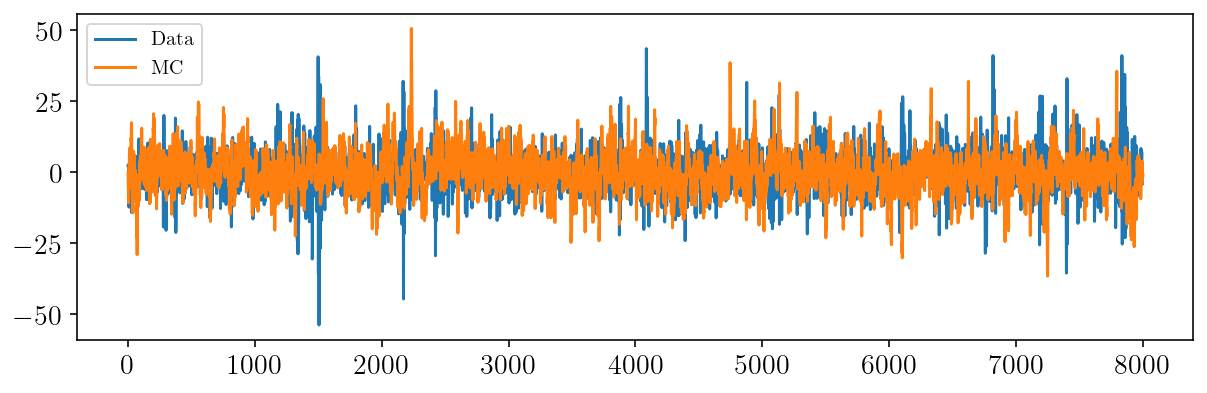

In [20]:
# === POD reconstruction ===

r = 2
Ur = U[:, :r]
Sr = np.diag(S[:r])
Vtr = modes_real[:r, :]
Vtr_sim = modes_sim[:r, :]

Q_real = Ur @ Sr @ Vtr
Q_sim = Ur @ Sr @ Vtr_sim

plt.figure(figsize=(10, 3))
plt.plot(Q_real[1, :], label='Data')
plt.plot(Q_sim[1, :], label='MC')
plt.legend()
plt.show()

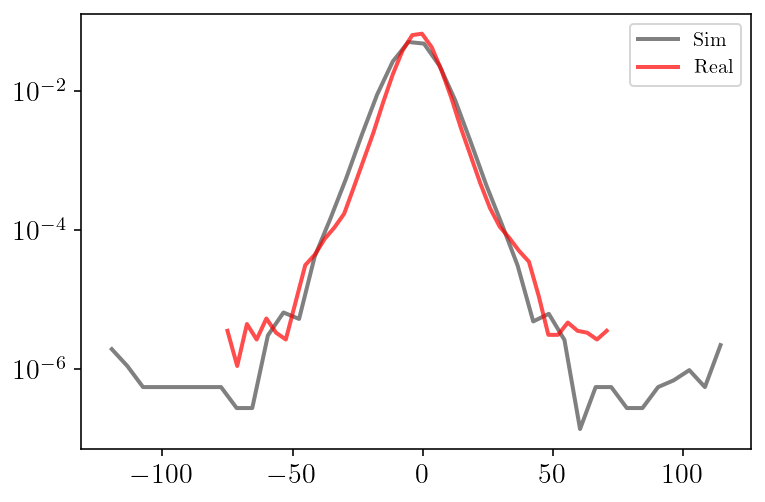

In [21]:
# === Histogram: Q_sim vs Q_real ===

data_heights, data_bins = np.histogram(Q_sim, bins=40, density=True)
sim_heights, sim_bins = np.histogram(0.9 * Q_real, bins=40, density=True)

plt.plot(data_bins[:-1], data_heights, c='grey', linewidth=2, label="Sim")
plt.plot(sim_bins[:-1], sim_heights, c='red', linewidth=2, alpha=0.7, label="Real")
plt.yscale("log")
plt.legend()
plt.show()

In [ ]:
# === Save reconstructed Q arrays ===

np.save(f'lang_reg_data6/{file}_Q_real.txt', np.array(Q_real))
np.save(f'lang_reg_data6/{file}_Q_sim.txt', np.array(0.9 * Q_sim))

(150, 8000)


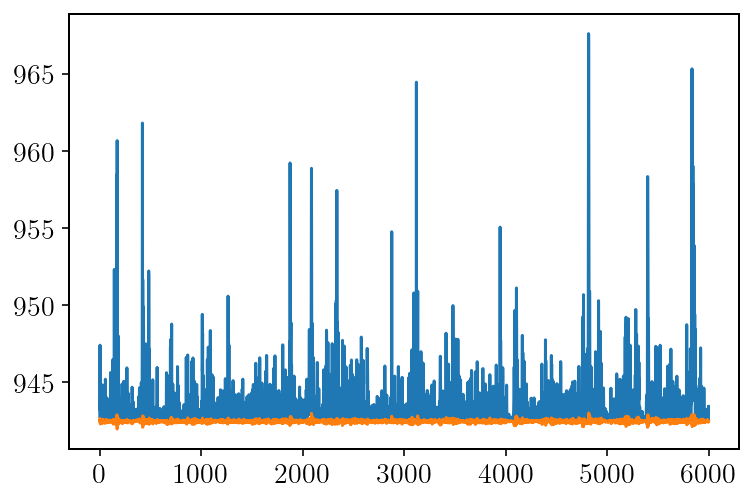

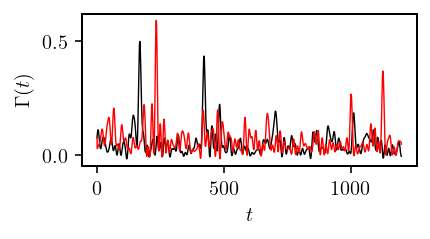

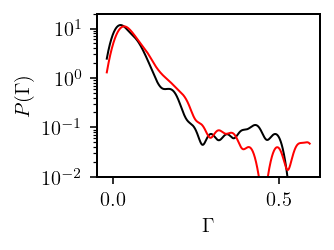

In [ ]:
# === Publication-quality deformation analysis ===

file = 200
Q_sim_pub = 1.1 * np.load(f'lang_reg_data6/{file}_Q_sim.txt.npy') + 150
Q_real_pub = np.load(f'lang_reg_data6/{file}_Q_real.txt.npy') + 150
print("Q_sim shape:", Q_sim_pub.shape)

x_gam, x_200, real_200, sim_200, y_data, y_sim = calc_deformation_pub(Q_sim_pub, Q_real_pub)
gam_original1 = y_data